In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import MDAnalysis.analysis.distances
import MDAnalysis as md
import mdtraj as mdj
import MDAnalysis.analysis.contacts
import pandas as pd
import MDAnalysis.analysis.rms
import os
from MDAnalysis.analysis.dihedrals import Dihedral
from MDAnalysis.analysis.rms import RMSF
from MDAnalysis.analysis import rms, align
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42

path = '/Volumes/Elements/PTM_project/PARK7/pS57/'

In [5]:
# dataframe
df = pd.DataFrame()
residues = np.arange(1,190)
df['Residue'] = residues

# isolated
nsims=3
rmsf = []
for i in range(1,nsims+1):
    dat = np.loadtxt(path+'sim{}/rmsf_CA.xvg'.format(i),skiprows=17)[:,1][:189]
    rmsf.append(dat)
rmsf = np.array(rmsf)
mu = np.mean(rmsf,axis=0)*10 # convert to Angstrom
err = np.std(rmsf,axis=0)*10/np.sqrt(nsims)

df['Isolated Avg.'] = mu
df['Isolated Err.'] = err

df.to_csv('RMSF_data_chainA.csv')
df[:10]

,Residue,Isolated Avg.,Isolated Err.
0,1,4.736667,0.067139
1,2,2.557333,0.071852
2,3,1.188000,0.052867
3,4,0.583667,0.005624
4,5,0.537333,0.001186
5,6,0.398667,0.001515
6,7,0.366667,0.001440
7,8,0.346000,0.002055
8,9,0.379667,0.003569
9,10,0.402000,0.006236


In [6]:
# dataframe
df = pd.DataFrame()
residues = np.arange(1,190)
df['Residue'] = residues

# isolated
nsims=3
rmsf = []
for i in range(1,nsims+1):
    dat = np.loadtxt(path+'sim{}/rmsf_CA.xvg'.format(i),skiprows=17)[:,1][189:]
    rmsf.append(dat)
rmsf = np.array(rmsf)
mu = np.mean(rmsf,axis=0)*10 # convert to Angstrom
err = np.std(rmsf,axis=0)*10/np.sqrt(nsims)

df['Isolated Avg.'] = mu
df['Isolated Err.'] = err

df.to_csv('RMSF_data_chainB.csv')
df[:10]

,Residue,Isolated Avg.,Isolated Err.
0,1,4.782000,0.028767
1,2,2.575333,0.014624
2,3,1.210667,0.043930
3,4,0.568000,0.009092
4,5,0.520333,0.005256
5,6,0.391667,0.003810
6,7,0.360667,0.003475
7,8,0.347000,0.004028
8,9,0.379333,0.006152
9,10,0.403667,0.011405


In [7]:
# dataframe
df = pd.DataFrame()
residues = np.arange(1,190)
df['Residue'] = residues

# isolated
nsims=3
rmsf = []
for i in range(1,nsims+1):
    dat = np.loadtxt(path+'sim{}/rmsf_CA.xvg'.format(i),skiprows=17)[:,1][:189]
    dat2 = np.loadtxt(path+'sim{}/rmsf_CA.xvg'.format(i),skiprows=17)[:,1][189:]
    
    rmsf.append(dat)
    rmsf.append(dat2)
rmsf = np.array(rmsf)
mu = np.mean(rmsf,axis=0)*10 # convert to Angstrom
err = np.std(rmsf,axis=0)*10/np.sqrt(nsims*2)

df['Isolated Avg.'] = mu
df['Isolated Err.'] = err

df.to_csv('RMSF_data_avgchain.csv')
df[:10]

,Residue,Isolated Avg.,Isolated Err.
0,1,4.759333,0.037675
1,2,2.566333,0.036846
2,3,1.199333,0.034678
3,4,0.575833,0.006229
4,5,0.528833,0.004393
5,6,0.395167,0.002499
6,7,0.363667,0.002244
7,8,0.346500,0.002270
8,9,0.379500,0.003557
9,10,0.402833,0.006508


In [8]:
# dataframe
df_phos = pd.read_csv('RMSF_data_avgchain.csv')
df = pd.read_csv('../unbiased_MD_analyses/RMSF_data_avgchain.csv')
dd = pd.DataFrame()
dd['Residue'] = df['Residue']
dd['Delta'] = df_phos['Isolated Avg.'] - df['Isolated Avg.']
dd['Error'] = np.sqrt(df_phos['Isolated Err.']**2 + df['Isolated Err.']**2)
dd.to_csv('deltaRMSF_avgchain_phos_minus_wt.csv')
dd

,Residue,Delta,Error
0,1,-0.300500,0.312998
1,2,-0.284000,0.286291
2,3,-0.226333,0.207512
3,4,-0.028667,0.020251
4,5,-0.007500,0.008052
...,...,...,...
184,185,0.182333,0.114614
185,186,0.237833,0.143811
186,187,0.233667,0.135132
187,188,0.193167,0.159895


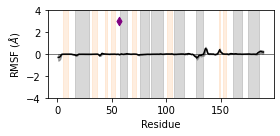

In [9]:
# average RMSF of chain A and chain B
df = pd.read_csv('deltaRMSF_avgchain_phos_minus_wt.csv')

ymax = 4

# secondary structure elements
# Beta strands based on DSSP:
beta_start = [5,16,32,44,49,58,69,76,86,101,107,127,148,152,161,175]
beta_end = [10,29,37,46,53,64,72,84,97,105,116,134,149,155,169,185]
beta_start = np.array(beta_start)
beta_end = np.array(beta_end)
strand_names = ['S1','H1','S2','S3','S4','H2','S5','H3','H4','S6','H5','H6','S7','S8','H7','H8']


plt.figure(figsize = (4,2))



plt.plot(df['Residue'],df['Delta'],color = 'black')
plt.fill_between(df['Residue'],df['Delta']-df['Error'],df['Delta']+df['Error'],color = 'black',alpha = 0.3)

    

plt.ylim(-ymax,ymax)
# secondary structure
#for i in range(len(beta_start)):
    #plt.axvspan(beta_start[i],beta_end[i],color = 'grey',alpha = 0.3)
#for i in range(len(beta_start)):
    #plt.text((beta_start[i]+beta_end[i])/2-3,ymax*0.85,strand_names[i],fontsize = 10)
    
for i in range(len(beta_start)):
    if 'H' in strand_names[i]:
        col='grey'
    elif 'S' in strand_names[i]:
        col='#FEC89A'
    plt.axvspan(beta_start[i],beta_end[i],color = col,alpha = 0.3)
#for i in range(len(beta_start)):
    #plt.text((beta_start[i]+beta_end[i])/2-3,ymax*0.85,strand_names[i],fontsize = 10)
    
# buried PTM sites
plt.scatter([57],[3],color = 'purple',marker='d')
#plt.scatter([57],[3],color = 'purple',marker='d')
#plt.scatter([47],[3],color = 'purple',marker='d')

plt.axhline(0,linewidth=0.5,color='black')

    
plt.xlabel('Residue')
plt.ylabel('RMSF ($\\AA$)')

plt.tight_layout()
plt.savefig('deltaRMSF_avgchain.pdf')
